# 🧠 Notebook 05: RAG Preparation and Knowledge Base

Welcome to the AI integration phase of our simulation! We're now going to add intelligence to our agents by creating a **knowledge base** and implementing a basic **Retrieval-Augmented Generation (RAG)** system.

**Today's Goals:**
1. **Create a Knowledge Base**: Build a collection of public health documents that our agents can reference.
2. **Implement Document Processing**: Use LangChain to process and chunk our documents.
3. **Build a Simple Retrieval System**: Create a basic search mechanism for our documents.
4. **Introduce PublicHealthAgencyAgent**: A new agent type that can query the knowledge base for guidance.
5. **Test the RAG System**: Demonstrate how agents can retrieve relevant information to make decisions.


In [8]:
## Cell 1: Import Libraries and Setup

# Standard imports from previous notebooks
import mesa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# New imports for RAG and document processing
import os
import json
from typing import List, Dict, Tuple
from dataclasses import dataclass
import warnings
warnings.filterwarnings("ignore")

# LangChain imports for document processing
try:
    # LangChain has become modular. We now import from specific packages.
    from langchain_text_splitters import RecursiveCharacterTextSplitter
    from langchain_community.embeddings import HuggingFaceEmbeddings
    from langchain_community.vectorstores import FAISS
    from langchain_core.documents import Document
    print("✅ LangChain libraries imported successfully")
except ImportError:
    print("⚠️  LangChain not installed. Installing required packages now...")
    import subprocess
    # We need to install the core, community, and text-splitter packages.
    subprocess.run(["pip", "install", "langchain", "langchain-community", "langchain-text-splitters", "sentence-transformers", "faiss-cpu"])
    from langchain_text_splitters import RecursiveCharacterTextSplitter
    from langchain_community.embeddings import HuggingFaceEmbeddings
    from langchain_community.vectorstores import FAISS
    from langchain_core.documents import Document
    print("✅ LangChain libraries installed and imported")

# Plotting settings
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (14, 10)

print("All libraries imported. Ready to build our knowledge base!")

✅ LangChain libraries imported successfully
All libraries imported. Ready to build our knowledge base!


In [9]:
public_health_documents = {
    "hospital_capacity_management.txt": """
HOSPITAL CAPACITY MANAGEMENT PROTOCOL

1. CAPACITY MONITORING
- Monitor bed occupancy rates hourly
- Maintain real-time dashboard of available beds
- Track ICU and general ward capacity separately
- Alert system when occupancy exceeds 80%

2. SURGE CAPACITY ACTIVATION
- Level 1 (80% capacity): Cancel elective procedures
- Level 2 (90% capacity): Implement early discharge protocols
- Level 3 (95% capacity): Activate overflow areas
- Level 4 (100% capacity): Implement crisis standards of care

3. RESOURCE ALLOCATION
- Prioritize beds based on medical acuity
- Maintain reserve capacity for emergencies
- Coordinate with regional hospital network
- Consider patient transfer to less affected facilities

4. STAFFING CONSIDERATIONS
- Cross-train staff for multiple departments
- Implement extended shift patterns during surges
- Coordinate with temporary staffing agencies
- Prioritize staff health and wellness
""",
    
    "epidemic_response_guidelines.txt": """
EPIDEMIC RESPONSE GUIDELINES

1. EARLY DETECTION AND MONITORING
- Establish surveillance systems for unusual disease patterns
- Monitor key indicators: infection rate, hospitalization rate, mortality
- Implement contact tracing protocols
- Coordinate with public health authorities

2. INFECTION CONTROL MEASURES
- Isolate confirmed cases immediately
- Implement quarantine protocols for exposed individuals
- Enhance cleaning and disinfection procedures
- Ensure adequate personal protective equipment (PPE)

3. COMMUNITY INTERVENTIONS
- Social distancing measures when transmission rate > 1.5
- Mask mandates in high-risk areas
- Limit large gatherings when hospital capacity > 70%
- School closures if pediatric cases increase rapidly

4. HEALTHCARE SYSTEM RESPONSE
- Activate emergency operations center
- Implement triage protocols
- Coordinate regional resource sharing
- Prepare for potential healthcare worker shortages
""",
    
    "resource_allocation_protocols.txt": """
RESOURCE ALLOCATION PROTOCOLS

1. VENTILATOR ALLOCATION
- Priority scoring based on clinical criteria
- Regular reassessment every 48-72 hours
- Consider short-term survivability
- Maintain ethical review committee

2. MEDICATION DISTRIBUTION
- Prioritize critical care medications
- Implement rationing protocols if supplies limited
- Coordinate with pharmaceutical suppliers
- Monitor expiration dates and rotate stock

3. PPE ALLOCATION
- Prioritize frontline healthcare workers
- Implement conservation strategies
- Extended use protocols for masks and gowns
- Regular supply chain monitoring

4. STAFFING ALLOCATION
- Deploy staff based on expertise and need
- Implement buddy system for inexperienced staff
- Cross-training programs for surge capacity
- Mental health support for healthcare workers

5. INTER-HOSPITAL TRANSFERS
- Transfer patients when local capacity exceeded
- Coordinate through regional coordination center
- Consider patient stability for transport
- Maintain communication with receiving facilities
""",
    
    "public_communication_strategy.txt": """
PUBLIC COMMUNICATION STRATEGY

1. CRISIS COMMUNICATION PRINCIPLES
- Provide timely, accurate, and transparent information
- Use multiple communication channels
- Address misinformation promptly
- Show empathy and understanding

2. KEY MESSAGING DURING OUTBREAKS
- Current situation and trends
- Protective measures individuals can take
- Healthcare system capacity and preparedness
- Available resources and support services

3. TARGET AUDIENCES
- General public
- Healthcare workers
- Vulnerable populations
- Community leaders and organizations

4. COMMUNICATION CHANNELS
- Official websites and social media
- Press conferences and media briefings
- Community partnerships
- Healthcare provider networks

5. MISINFORMATION MANAGEMENT
- Monitor social media for false information
- Provide fact-based corrections
- Partner with trusted community voices
- Educate public on reliable information sources
"""
}

# Save documents to files (simulating a real document collection)
os.makedirs("knowledge_base", exist_ok=True)
for filename, content in public_health_documents.items():
    with open(f"knowledge_base/{filename}", "w") as f:
        f.write(content)

print(f"✅ Created knowledge base with {len(public_health_documents)} documents:")
for filename in public_health_documents.keys():
    print(f"   - {filename}")

✅ Created knowledge base with 4 documents:
   - hospital_capacity_management.txt
   - epidemic_response_guidelines.txt
   - resource_allocation_protocols.txt
   - public_communication_strategy.txt


### Document Processing and Vector Store Creation

In [10]:
class KnowledgeBase:
    """A knowledge base system for storing and retrieving public health documents."""
    
    def __init__(self, documents_path="knowledge_base"):
        self.documents_path = documents_path
        self.documents = []
        self.vectorstore = None
        self.embeddings = HuggingFaceEmbeddings(
            model_name="sentence-transformers/all-MiniLM-L6-v2",
            model_kwargs={'device': 'cpu'}
        )
        self.text_splitter = RecursiveCharacterTextSplitter(
            chunk_size=500,
            chunk_overlap=50,
            length_function=len
        )
        
    def load_documents(self):
        """Load all documents from the documents path."""
        self.documents = []
        for filename in os.listdir(self.documents_path):
            if filename.endswith('.txt'):
                filepath = os.path.join(self.documents_path, filename)
                with open(filepath, 'r') as f:
                    content = f.read()
                doc = Document(page_content=content, metadata={"source": filename})
                print(f"✅ Loaded document: {filename}")
                self.documents.append(doc)
        print(f"✅ Loaded {len(self.documents)} documents")
        
    def create_vectorstore(self):
        """Process documents and create vector store for similarity search."""
        if not self.documents:
            self.load_documents()
            
        # Split documents into chunks
        chunks = self.text_splitter.split_documents(self.documents)
        print(f"✅ Split documents into {len(chunks)} chunks")
        
        # Create vector store
        self.vectorstore = FAISS.from_documents(chunks, self.embeddings)
        print("✅ Created vector store for similarity search")
        
    def search(self, query: str, k: int = 3) -> List[Dict]:
        """Search for relevant documents based on the query."""
        if not self.vectorstore:
            self.create_vectorstore()
            
        results = self.vectorstore.similarity_search(query, k=k)
        
        return [
            {
                "content": doc.page_content,
                "source": doc.metadata.get("source", "unknown"),
                "relevance_score": i + 1  # Simple ranking
            }
            for i, doc in enumerate(results)
        ]

# Initialize and test the knowledge base
print("Initializing knowledge base...")
kb = KnowledgeBase()
kb.load_documents()
kb.create_vectorstore()

print("Knowledge base initialized and vector store created.")


Initializing knowledge base...
✅ Loaded document: epidemic_response_guidelines.txt
✅ Loaded document: hospital_capacity_management.txt
✅ Loaded document: public_communication_strategy.txt
✅ Loaded document: resource_allocation_protocols.txt
✅ Loaded 4 documents
✅ Split documents into 10 chunks
✅ Created vector store for similarity search
Knowledge base initialized and vector store created.


In [11]:
# Test the search functionality
test_query = "What should we do when hospital capacity is exceeded?"
results = kb.search(test_query)

print(f"\n🔍 Test Search Query: '{test_query}'")
print("📋 Search Results:")
for i, result in enumerate(results, 1):
    print(f"\n--- Result {i} (Source: {result['source']}) ---")
    print(result['content'][:200] + "..." if len(result['content']) > 200 else result['content'])


🔍 Test Search Query: 'What should we do when hospital capacity is exceeded?'
📋 Search Results:

--- Result 1 (Source: hospital_capacity_management.txt) ---
3. RESOURCE ALLOCATION
- Prioritize beds based on medical acuity
- Maintain reserve capacity for emergencies
- Coordinate with regional hospital network
- Consider patient transfer to less affected fa...

--- Result 2 (Source: hospital_capacity_management.txt) ---
HOSPITAL CAPACITY MANAGEMENT PROTOCOL

1. CAPACITY MONITORING
- Monitor bed occupancy rates hourly
- Maintain real-time dashboard of available beds
- Track ICU and general ward capacity separately
- A...

--- Result 3 (Source: resource_allocation_protocols.txt) ---
5. INTER-HOSPITAL TRANSFERS
- Transfer patients when local capacity exceeded
- Coordinate through regional coordination center
- Consider patient stability for transport
- Maintain communication with ...


### Public Health Agency Agent

In [12]:
class PublicHealthAgencyAgent(mesa.Agent):
    """An agent representing a public health agency that can query the knowledge base."""
    
    def __init__(self, unique_id, model, knowledge_base):
        super().__init__(unique_id, model)
        self.knowledge_base = knowledge_base
        self.recommendations = []
        self.last_assessment_step = 0
        self.assessment_interval = 10  # Assess situation every 10 steps
        
    def step(self):
        """Assess the current situation and provide recommendations if needed."""
        current_step = self.model.schedule.steps
        
        # Only assess periodically
        if current_step - self.last_assessment_step >= self.assessment_interval:
            self.assess_situation()
            self.last_assessment_step = current_step
    
    def assess_situation(self):
        """Assess the current epidemic situation and query knowledge base for guidance."""
        # Get current statistics
        total_hospitalized = sum(h.patients for h in self.model.hospitals)
        total_capacity = sum(h.capacity for h in self.model.hospitals)
        occupancy_rate = total_hospitalized / total_capacity if total_capacity > 0 else 0
        
        infected_untreated = sum(1 for agent in self.model.schedule.agents 
                               if hasattr(agent, 'state') and agent.state == State.INFECTED_UNTREATED)
        
        # Determine what guidance to seek based on current conditions
        queries = []
        
        if occupancy_rate > 0.8:
            queries.append("hospital capacity management surge response")
            
        if infected_untreated > 50:
            queries.append("epidemic response community interventions")
            
        if occupancy_rate > 0.9:
            queries.append("resource allocation protocols critical care")
        
        # Query knowledge base and generate recommendations
        new_recommendations = []
        for query in queries:
            results = self.knowledge_base.search(query, k=1)
            if results:
                recommendation = self.extract_recommendation(results[0], occupancy_rate, infected_untreated)
                if recommendation:
                    new_recommendations.append(recommendation)
        
        # Store new recommendations
        self.recommendations.extend(new_recommendations)
        
        # Print recommendations (in real system, this would trigger actions)
        if new_recommendations:
            print(f"\n🏥 PUBLIC HEALTH AGENCY - Step {self.model.schedule.steps}")
            print(f"   Hospital Occupancy: {occupancy_rate:.1%} ({total_hospitalized}/{total_capacity})")
            print(f"   Untreated Infected: {infected_untreated}")
            for rec in new_recommendations:
                print(f"   📋 RECOMMENDATION: {rec}")
    
    def extract_recommendation(self, search_result, occupancy_rate, infected_untreated):
        """Extract actionable recommendation from search result."""
        content = search_result['content'].lower()
        
        # Simple rule-based recommendation extraction
        if occupancy_rate > 0.9 and 'crisis standards' in content:
            return "ACTIVATE CRISIS STANDARDS OF CARE - Hospital capacity critical"
        elif occupancy_rate > 0.8 and 'cancel elective' in content:
            return "Cancel elective procedures to free up hospital beds"
        elif infected_untreated > 50 and 'social distancing' in content:
            return "Consider implementing social distancing measures"
        elif 'transfer' in content and occupancy_rate > 0.7:
            return "Coordinate patient transfers to less affected facilities"
        
        return None

print("✅ PublicHealthAgencyAgent class defined with RAG capabilities")

✅ PublicHealthAgencyAgent class defined with RAG capabilities


### Our Person , Hospital and Epidemic Agents

In [18]:
class State:
    SUSCEPTIBLE = 0
    INFECTED_UNTREATED = 1
    HOSPITALIZED = 2
    RECOVERED = 3

class HospitalAgent(mesa.Agent):
    """Hospital agent from previous notebook (simplified)."""
    def __init__(self, unique_id, model, capacity=25):
        super().__init__(unique_id, model)
        self.capacity = capacity
        self.patients = 0

    @property
    def is_full(self):
        return self.patients >= self.capacity
        
    def admit_patient(self):
        if not self.is_full:
            self.patients += 1
            return True
        return False

    def discharge_patient(self):
        if self.patients > 0:
            self.patients -= 1
    
    def step(self):
        pass

print("✅ HospitalAgent class defined with RAG capabilities")

class PersonAgent(mesa.Agent):
    """Person agent from previous notebook (simplified)."""
    def __init__(self, unique_id, model, recovery_rate, hospitalized_recovery_rate):
        super().__init__(unique_id, model)
        self.state = State.SUSCEPTIBLE
        self.recovery_rate = recovery_rate
        self.hospitalized_recovery_rate = hospitalized_recovery_rate
        self.hospital_id = None

    def step(self):
        if self.state == State.INFECTED_UNTREATED:
            self.try_to_get_hospitalized()
            self.infect_neighbors()
            self.try_to_recover(self.recovery_rate)
        elif self.state == State.HOSPITALIZED:
            self.try_to_recover(self.hospitalized_recovery_rate)
        
        if self.state != State.HOSPITALIZED:
            self.move()

    def try_to_recover(self, rate):
        if self.random.random() < rate:
            if self.state == State.HOSPITALIZED:
                hospital = next((agent for agent in self.model.schedule.agents if isinstance(agent, HospitalAgent) and agent.unique_id == self.hospital_id), None)
                if hospital:
                    hospital.discharge_patient()
                self.hospital_id = None
            self.state = State.RECOVERED
            
    def try_to_get_hospitalized(self):
        available_hospitals = [h for h in self.model.hospitals if not h.is_full]
        if not available_hospitals:
            return
        
        closest_hospital = min(available_hospitals, key=lambda h: self.distance_to(h))
        
        if self.pos == closest_hospital.pos:
            if closest_hospital.admit_patient():
                self.state = State.HOSPITALIZED
                self.hospital_id = closest_hospital.unique_id
        else:
            self.move_towards(closest_hospital)

    def move(self):
        possible_steps = self.model.grid.get_neighborhood(self.pos, moore=True)
        new_position = self.random.choice(possible_steps)
        self.model.grid.move_agent(self, new_position)
        
    def move_towards(self, target_agent):
        dx = target_agent.pos[0] - self.pos[0]
        dy = target_agent.pos[1] - self.pos[1]
        if abs(dx) > abs(dy):
            new_x = self.pos[0] + np.sign(dx)
            new_y = self.pos[1]
        else:
            new_x = self.pos[0]
            new_y = self.pos[1] + np.sign(dy)
        new_pos = (max(0, min(self.model.grid.width - 1, int(new_x))),
                   max(0, min(self.model.grid.height - 1, int(new_y))))
        self.model.grid.move_agent(self, new_pos)

    def distance_to(self, other_agent):
        return abs(self.pos[0] - other_agent.pos[0]) + abs(self.pos[1] - other_agent.pos[1])

    def infect_neighbors(self):
        cellmates = self.model.grid.get_cell_list_contents([self.pos])
        for other in cellmates:
            if isinstance(other, PersonAgent) and other.state == State.SUSCEPTIBLE:
                if self.random.random() < self.model.transmission_rate:
                    other.state = State.INFECTED_UNTREATED


print("✅PersonAgent classes defined with RAG capabilities")


✅ HospitalAgent class defined with RAG capabilities
✅PersonAgent classes defined with RAG capabilities


In [19]:
class EpidemicModelWithRAG(mesa.Model):
    """Enhanced epidemic model with RAG-enabled public health agency."""
    
    def __init__(self, N=100, width=50, height=50, transmission_rate=0.3, 
                 recovery_rate=0.1, hospitalized_recovery_rate=0.3, 
                 p_initial_infected=0.1, num_hospitals=5, hospital_capacity=20,
                 knowledge_base=None):
        
        super().__init__()
        self.num_agents = N
        self.transmission_rate = transmission_rate
        self.grid = mesa.space.MultiGrid(width, height, True)
        self.schedule = mesa.time.RandomActivation(self)
        self.running = True
        self.hospitals = []

        # Create Hospital Agents
        hospital_id_start = N
        for i in range(num_hospitals):
            hid = hospital_id_start + i
            h = HospitalAgent(hid, self, hospital_capacity)
            self.hospitals.append(h)
            self.schedule.add(h)
            x = self.random.randrange(self.grid.width)
            y = self.random.randrange(self.grid.height)
            self.grid.place_agent(h, (x, y))

        # Create Person Agents
        for i in range(self.num_agents):
            a = PersonAgent(i, self, recovery_rate, hospitalized_recovery_rate)
            self.schedule.add(a)
            x = self.random.randrange(self.grid.width)
            y = self.random.randrange(self.grid.height)
            self.grid.place_agent(a, (x, y))
            if self.random.random() < p_initial_infected:
                a.state = State.INFECTED_UNTREATED

        # Create Public Health Agency Agent with RAG capabilities
        if knowledge_base:
            pha_id = hospital_id_start + num_hospitals
            self.public_health_agency = PublicHealthAgencyAgent(pha_id, self, knowledge_base)
            self.schedule.add(self.public_health_agency)
        else:
            self.public_health_agency = None

        # Data Collection
        self.datacollector = mesa.DataCollector(
            model_reporters={
                "Susceptible": lambda m: self.count_states(m, PersonAgent, State.SUSCEPTIBLE),
                "Infected (Untreated)": lambda m: self.count_states(m, PersonAgent, State.INFECTED_UNTREATED),
                "Hospitalized": lambda m: self.count_states(m, PersonAgent, State.HOSPITALIZED),
                "Recovered": lambda m: self.count_states(m, PersonAgent, State.RECOVERED),
                "Total Hospital Occupancy": lambda m: sum(h.patients for h in m.hospitals),
                "Hospital Occupancy Rate": lambda m: sum(h.patients for h in m.hospitals) / sum(h.capacity for h in m.hospitals)
            }
        )
    
    @staticmethod
    def count_states(model, agent_type, state):
        return sum(1 for a in model.schedule.agents if isinstance(a, agent_type) and a.state == state)

    def step(self):
        self.datacollector.collect(self)
        self.schedule.step()
        if self.count_states(self, PersonAgent, State.INFECTED_UNTREATED) == 0 and \
           self.count_states(self, PersonAgent, State.HOSPITALIZED) == 0:
            self.running = False

print("✅ EpidemicModelWithRAG class defined with RAG integration")

✅ EpidemicModelWithRAG class defined with RAG integration


### Run Simulation with RAG System

In [24]:
# Simulation Parameters
POPULATION = 800
GRID_WIDTH = 40
GRID_HEIGHT = 40
TRANSMISSION_RATE = 0.9      # Higher transmission rate to stress the system
RECOVERY_RATE = 0.02         # Slower recovery to create more pressure
HOSPITALIZED_RECOVERY_RATE = 0.125
INITIAL_INFECTED_P = 0.03

# Healthcare System Parameters
NUM_HOSPITALS = 3
HOSPITAL_CAPACITY = 12       # Lower capacity to trigger RAG recommendations
TOTAL_CAPACITY = NUM_HOSPITALS * HOSPITAL_CAPACITY

SIMULATION_STEPS = 100

print("🚀 Starting RAG-Enhanced Epidemic Simulation")
print(f"Population: {POPULATION}, Hospitals: {NUM_HOSPITALS}, Total Beds: {TOTAL_CAPACITY}")
print("-" * 60)

# Create and run the model with RAG system
model = EpidemicModelWithRAG(
    N=POPULATION,
    width=GRID_WIDTH,
    height=GRID_HEIGHT,
    transmission_rate=TRANSMISSION_RATE,
    recovery_rate=RECOVERY_RATE,
    hospitalized_recovery_rate=HOSPITALIZED_RECOVERY_RATE,
    p_initial_infected=INITIAL_INFECTED_P,
    num_hospitals=NUM_HOSPITALS,
    hospital_capacity=HOSPITAL_CAPACITY,
    knowledge_base=kb
)

# Run simulation
for i in range(SIMULATION_STEPS):
    if model.running:
        model.step()
    else:
        print(f"\nSimulation ended at step {i} - no more infections")
        break

print(f"\n✅ Simulation completed after {min(i+1, SIMULATION_STEPS)} steps")

# Get results
results_df = model.datacollector.get_model_vars_dataframe()

🚀 Starting RAG-Enhanced Epidemic Simulation
Population: 800, Hospitals: 3, Total Beds: 36
------------------------------------------------------------

🏥 PUBLIC HEALTH AGENCY - Step 20
   Hospital Occupancy: 91.7% (33/36)
   Untreated Infected: 206
   📋 RECOMMENDATION: ACTIVATE CRISIS STANDARDS OF CARE - Hospital capacity critical

🏥 PUBLIC HEALTH AGENCY - Step 30
   Hospital Occupancy: 88.9% (32/36)
   Untreated Infected: 151
   📋 RECOMMENDATION: Cancel elective procedures to free up hospital beds

🏥 PUBLIC HEALTH AGENCY - Step 40
   Hospital Occupancy: 83.3% (30/36)
   Untreated Infected: 111
   📋 RECOMMENDATION: Cancel elective procedures to free up hospital beds

🏥 PUBLIC HEALTH AGENCY - Step 50
   Hospital Occupancy: 94.4% (34/36)
   Untreated Infected: 68
   📋 RECOMMENDATION: ACTIVATE CRISIS STANDARDS OF CARE - Hospital capacity critical

🏥 PUBLIC HEALTH AGENCY - Step 60
   Hospital Occupancy: 83.3% (30/36)
   Untreated Infected: 34
   📋 RECOMMENDATION: Cancel elective procedures

### Visualizing Results and RAG Recommendations


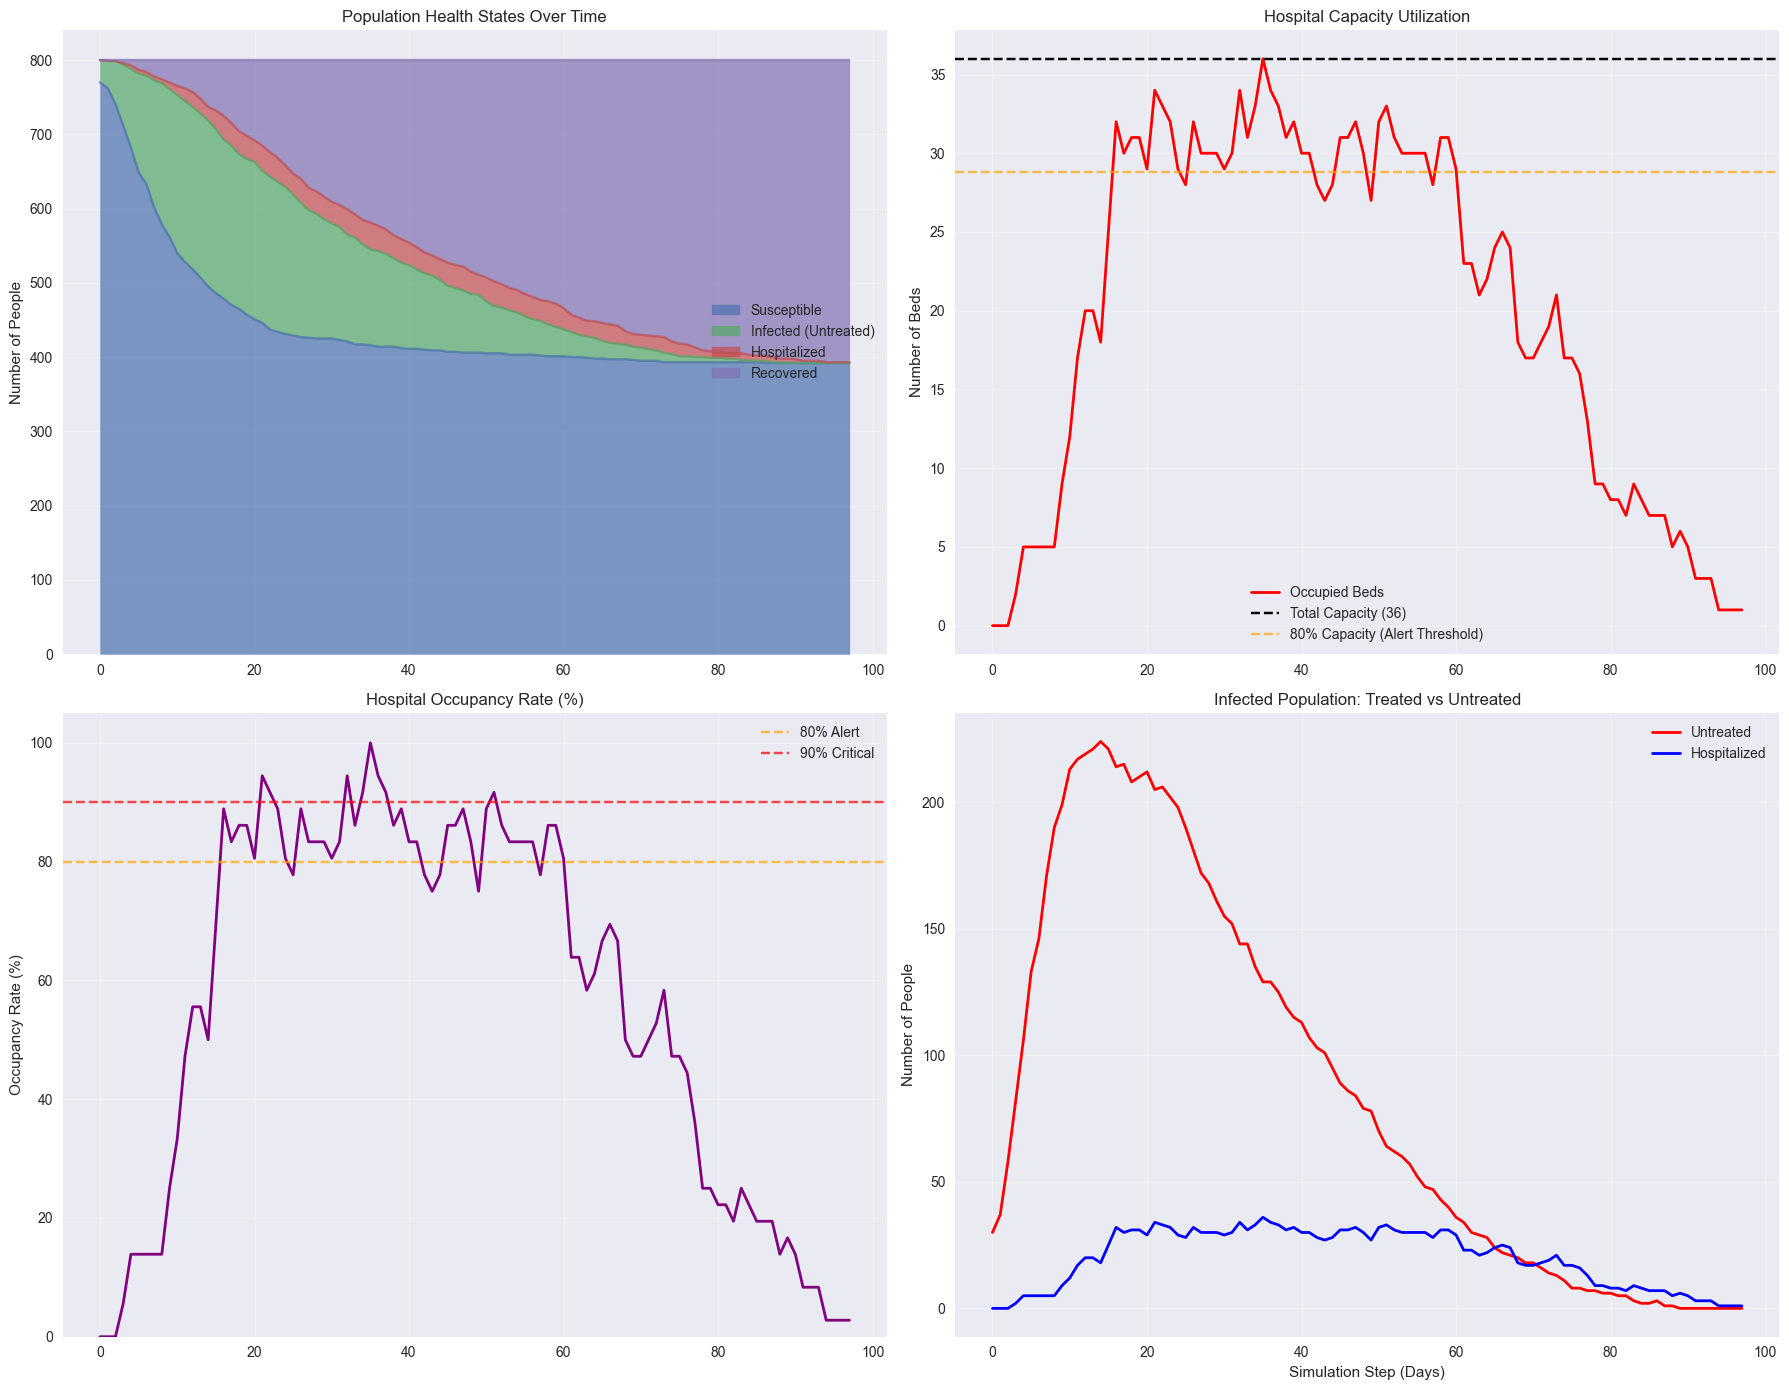


📊 FINAL SIMULATION ANALYSIS
🏥 Peak hospital occupancy rate: 100.0%
🔴 Peak untreated infected: 224
🔵 Peak hospitalized: 36
🚨 CRITICAL: Healthcare system was severely strained

🧠 RAG SYSTEM GENERATED 5 RECOMMENDATIONS:
   1. ACTIVATE CRISIS STANDARDS OF CARE - Hospital capacity critical
   2. Cancel elective procedures to free up hospital beds
   3. Cancel elective procedures to free up hospital beds
   4. ACTIVATE CRISIS STANDARDS OF CARE - Hospital capacity critical
   5. Cancel elective procedures to free up hospital beds


In [25]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 14))

# Plot 1: Population States Over Time
results_df[["Susceptible", "Infected (Untreated)", "Hospitalized", "Recovered"]].plot(
    ax=ax1, kind='area', stacked=True, alpha=0.7,
    title='Population Health States Over Time'
)
ax1.set_ylabel("Number of People")
ax1.grid(True, alpha=0.3)
ax1.legend(loc='right')

# Plot 2: Hospital System Metrics
ax2.plot(results_df.index, results_df["Total Hospital Occupancy"], 
         label="Occupied Beds", linewidth=2, color='red')
ax2.axhline(y=TOTAL_CAPACITY, color='black', linestyle='--', 
           label=f'Total Capacity ({TOTAL_CAPACITY})')
ax2.axhline(y=TOTAL_CAPACITY * 0.8, color='orange', linestyle='--', alpha=0.7,
           label='80% Capacity (Alert Threshold)')
ax2.set_title('Hospital Capacity Utilization')
ax2.set_ylabel("Number of Beds")
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Occupancy Rate
occupancy_rate = results_df["Hospital Occupancy Rate"] * 100
ax3.plot(occupancy_rate.index, occupancy_rate, linewidth=2, color='purple')
ax3.axhline(y=80, color='orange', linestyle='--', alpha=0.7, label='80% Alert')
ax3.axhline(y=90, color='red', linestyle='--', alpha=0.7, label='90% Critical')
ax3.set_title('Hospital Occupancy Rate (%)')
ax3.set_ylabel("Occupancy Rate (%)")
ax3.set_ylim(0, 105)
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Infected Population Breakdown
ax4.plot(results_df.index, results_df["Infected (Untreated)"], 
         label="Untreated", linewidth=2, color='red')
ax4.plot(results_df.index, results_df["Hospitalized"], 
         label="Hospitalized", linewidth=2, color='blue')
ax4.set_title('Infected Population: Treated vs Untreated')
ax4.set_ylabel("Number of People")
ax4.set_xlabel("Simulation Step (Days)")
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final analysis
peak_occupancy_rate = results_df["Hospital Occupancy Rate"].max()
peak_untreated = results_df["Infected (Untreated)"].max()
peak_hospitalized = results_df["Hospitalized"].max()

print("\n" + "="*60)
print("📊 FINAL SIMULATION ANALYSIS")
print("="*60)
print(f"🏥 Peak hospital occupancy rate: {peak_occupancy_rate:.1%}")
print(f"🔴 Peak untreated infected: {peak_untreated}")
print(f"🔵 Peak hospitalized: {peak_hospitalized}")

if peak_occupancy_rate >= 0.9:
    print("🚨 CRITICAL: Healthcare system was severely strained")
elif peak_occupancy_rate >= 0.8:
    print("⚠️  WARNING: Healthcare system experienced high stress")
else:
    print("✅ Healthcare system managed the outbreak effectively")

# Display RAG recommendations that were generated
if hasattr(model, 'public_health_agency') and model.public_health_agency:
    recommendations = model.public_health_agency.recommendations
    if recommendations:
        print(f"\n🧠 RAG SYSTEM GENERATED {len(recommendations)} RECOMMENDATIONS:")
        for i, rec in enumerate(recommendations, 1):
            print(f"   {i}. {rec}")
    else:
        print("\n🧠 RAG SYSTEM: No critical recommendations were triggered")

### Testing RAG Directly

In [26]:
test_queries = [
    "What to do when hospitals are at full capacity?",
    "How to manage ventilator shortages during pandemic?",
    "When should we implement social distancing measures?",
    "How to communicate with the public during health crisis?",
    "What are the protocols for inter-hospital patient transfers?"
]

print("🔍 TESTING RAG SYSTEM WITH VARIOUS PUBLIC HEALTH QUERIES")
print("="*70)

for i, query in enumerate(test_queries, 1):
    print(f"\n📝 Query {i}: {query}")
    print("-" * 50)
    
    results = kb.search(query, k=2)
    
    for j, result in enumerate(results, 1):
        print(f"\n📄 Result {j} (Source: {result['source']}):")
        # Show first 300 characters of the result
        content_preview = result['content'][:300] + "..." if len(result['content']) > 300 else result['content']
        print(content_preview)

print("\n" + "="*70)
print("✅ RAG system successfully retrieves relevant information for decision-making!")

🔍 TESTING RAG SYSTEM WITH VARIOUS PUBLIC HEALTH QUERIES

📝 Query 1: What to do when hospitals are at full capacity?
--------------------------------------------------

📄 Result 1 (Source: hospital_capacity_management.txt):
3. RESOURCE ALLOCATION
- Prioritize beds based on medical acuity
- Maintain reserve capacity for emergencies
- Coordinate with regional hospital network
- Consider patient transfer to less affected facilities

4. STAFFING CONSIDERATIONS
- Cross-train staff for multiple departments
- Implement extend...

📄 Result 2 (Source: hospital_capacity_management.txt):
HOSPITAL CAPACITY MANAGEMENT PROTOCOL

1. CAPACITY MONITORING
- Monitor bed occupancy rates hourly
- Maintain real-time dashboard of available beds
- Track ICU and general ward capacity separately
- Alert system when occupancy exceeds 80%

2. SURGE CAPACITY ACTIVATION
- Level 1 (80% capacity): Cance...

📝 Query 2: How to manage ventilator shortages during pandemic?
-------------------------------------------------

# 📈 Project Summary & Next Steps

This notebook successfully demonstrates a powerful proof-of-concept for an AI-enhanced agent-based model. Here's a summary of what has been accomplished and the clear paths for future development.

---

## ✅ Key Accomplishments

*   **Multi-Agent Simulation**: A dynamic environment was created with three distinct agent types (`PersonAgent`, `HospitalAgent`, `PublicHealthAgencyAgent`), each with its own behaviors and roles.
*   **Resource Contention**: The model effectively simulates the core challenge of an epidemic: `PersonAgent`s competing for a finite number of hospital beds, allowing for the study of healthcare system strain.
*   **Knowledge Base Creation**: A vector database was successfully built from policy documents, serving as the "long-term memory" for the AI agent.
*   **Intelligent Retrieval (The "R" in RAG)**: Using a `sentence-transformers` model, the `KnowledgeBase` performs semantic searches, understanding the *meaning* of a query to retrieve conceptually related information.
*   **AI-Informed Agent Behavior**: The `PublicHealthAgencyAgent` can observe the simulation, identify a problem (e.g., high hospital occupancy), formulate a query, and retrieve relevant guidance.

---

## ⚠️ Limitations & Future Work

While the foundation is strong, there are clear limitations that point toward exciting future work.

*   **No True "Generation" (The "G" in RAG)**: The system is not yet truly "generative." The `PublicHealthAgencyAgent` uses hardcoded `if/elif` rules to make decisions based on keywords in the retrieved text. The "decision" is made by your code, not a generative AI.
    *   **Next Step**: Integrate a true Large Language Model (LLM) like one from the `HuggingFaceHub` or `Ollama` to generate nuanced, context-aware recommendations instead of using simple rules.

*   **Static, One-Way Recommendations**: The agent's recommendations are printed but do not feed back into the simulation to change its parameters. For example, a "social distancing" recommendation does not actually lower the `TRANSMISSION_RATE`.
    *   **Next Step**: Implement a feedback loop where the agent's recommendations directly modify model parameters, creating a truly adaptive simulation.

*   **Simplified Agent Behavior**: `PersonAgent`s are deterministic and always try to go to the hospital when sick.
    *   **Next Step**: Introduce more realistic agent behavior, such as probabilistic decision-making (e.g., only 20% of sick people seek hospitalization) or varied responses to public health communications.

*   **Centralized Intelligence**: All the "intelligence" is located in a single `PublicHealthAgencyAgent`.
    *   **Next Step**: Distribute decision-making capabilities. Allow individual hospitals or even groups of people to query the knowledge base for guidance, creating a more complex and realistic simulation.